# Environment

## Imports

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import edgepython as ep
from tqdm.auto import tqdm
import anndata as ad
import scanpy as sc

## Helper functions

In [2]:
def one_vs_all_contrast(design_df, target_celltype):
    contrast = pd.Series(0.0, index=design_df.columns)

    target_col = f"ct_{target_celltype}"
    celltype_cols = [c for c in design_df.columns if c.startswith("ct_")]
    other_cols = [c for c in celltype_cols if c != target_col]

    if target_col not in design_df.columns:
        raise ValueError(f"{target_col} not found")

    contrast[target_col] = 1.0
    contrast[other_cols] = -1.0 / len(other_cols)

    return contrast.values

# Differential accessibility analysis

## Create dataset

In [ ]:
# --- ground truth effects ---
rng = np.random.default_rng(4)

n_peaks = 1000
celltypes = ["A", "B", "C", "D"]
samples   = ["sample1", "sample2", "sample3", "sample4"]
n_cells_per_ct = 40  # cells per celltype

# baseline log-mean per peak
base_log_mean = rng.normal(2, 0.5, size=n_peaks)

# celltype effects in log-scale (A is reference)
celltype_effect = {"A": 0, "B": 0.5, "C": -0.3, "D": 0.8}

# sample effects (batch/donor noise)
sample_effect = {s: rng.normal(0, 0.2) for s in samples}

# --- build obs ---
obs = pd.DataFrame({
    "celltype": np.repeat(celltypes, n_cells_per_ct),
    "sample_id": (samples * (n_cells_per_ct // len(samples))) * len(celltypes),
}).astype("category")

# --- sample counts per cell ---
counts = np.zeros((len(obs), n_peaks), dtype=int)

for i, (ct, samp) in enumerate(zip(obs["celltype"], obs["sample_id"])):
    log_mean = base_log_mean + celltype_effect[ct] + sample_effect[samp]
    mu = np.exp(log_mean)
    r  = 10
    p  = r / (r + mu)
    counts[i] = rng.negative_binomial(n=r, p=p)

adata = ad.AnnData(
    obs=obs,
    var=pd.DataFrame(index=[f"peak{i}" for i in range(n_peaks)]),
    layers={"sum": counts},
)

adata.write_h5ad("data/adata/toy_example.h5ad")

/nfs/users/nfs_c/cellgeni-su/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


## Preprocess

Calculate total counts per sample and per peak, for both sum and mean layers

In [4]:
adata.obs["total_counts_sum"] = adata.layers["sum"].sum(axis=1)
adata.var["total_counts_sum"] = adata.layers["sum"].sum(axis=0)
adata

AnnData object with n_obs × n_vars = 160 × 1000
    obs: 'celltype', 'sample_id', 'total_counts_sum'
    var: 'total_counts_sum'
    layers: 'sum'

In [5]:
adata.obs.head()

,celltype,sample_id,total_counts_sum
0,A,sample1,9411
1,A,sample2,7621
2,A,sample3,6588
3,A,sample4,7575
4,A,sample1,9521


Calculate CPMs

In [6]:
adata.X = adata.layers["sum"].copy()
sc.pp.normalize_total(adata, target_sum=1e6)

Filter peaks with low number of fragmetns

In [7]:
%%time

global_keep = pd.Series(False, index=adata.var_names)

min_cpm = 30.0
min_reps = 5

for ct in adata.obs["celltype"].cat.categories:
    cells = adata.obs[adata.obs["celltype"] == ct].index
    keep_peaks = (adata[cells].X >= min_cpm).sum(axis=0) >= min_reps
    global_keep |= keep_peaks

print(f"Keeping {global_keep.sum()} peaks out of {adata.n_vars} total peaks")

Keeping 1000 peaks out of 1000 total peaks
CPU times: user 16.6 ms, sys: 3.03 ms, total: 19.6 ms
Wall time: 18.2 ms


Let's also select peak group that are present in specific cell types

In [8]:
%%time

min_level = 10
ct2peaks = dict()
for ct in adata.obs["celltype"].cat.categories:
    cells = adata.obs[adata.obs["celltype"] == ct].index
    keep_peaks = adata[cells].layers["sum"].mean(axis=0) >= min_level
    ct2peaks[ct] = adata.var_names[keep_peaks]
    print(f"{ct}: {keep_peaks.sum()} peaks with mean number of fragments >= {min_level}")

ct_peaks = list(set.union(*[set(p) for p in ct2peaks.values()]))
print(f"Keeping {len(ct_peaks)} peaks out of {adata.n_vars} total peaks")

A: 238 peaks with mean number of fragments >= 10
B: 597 peaks with mean number of fragments >= 10
C: 88 peaks with mean number of fragments >= 10
D: 801 peaks with mean number of fragments >= 10
Keeping 801 peaks out of 1000 total peaks
CPU times: user 23.8 ms, sys: 34 μs, total: 23.8 ms
Wall time: 49.8 ms


## Fit a model

Create a design matrix for the differential accessibility analysis. We will use the cell type annotation as the main variable of interest, and we will also include the sample ID as a factor to account for batch effects

In [9]:
celltype_design = pd.get_dummies(
    adata.obs.celltype.str.replace(" ", "_").astype("category"),
    prefix="ct",
    drop_first=False,
    dtype=float
)

sample_design = pd.get_dummies(
    adata.obs.sample_id.astype("category"),
    prefix="sample",
    drop_first=True,
    dtype=float
)

design_df = pd.concat([celltype_design, sample_design], axis=1).astype(float)

print(design_df.shape)
print("rank:", np.linalg.matrix_rank(design_df.values))
print("n columns:", design_df.shape[1])

assert np.linalg.matrix_rank(design_df.values) == design_df.shape[1], "Design is not full rank"

(160, 7)
rank: 7
n columns: 7


Create a DGEList object for `edgepython`

In [10]:
%%time

keep = adata.var_names[global_keep]
y = ep.make_dgelist(
    adata[:, keep].layers["sum"].T,
    group=adata.obs["celltype"].values,
    genes=adata[:, keep].var,
    samples=adata.obs,
    remove_zeros=True
)

y

CPU times: user 15.7 ms, sys: 0 ns, total: 15.7 ms
Wall time: 34.5 ms


DGEList with 1000 rows and 160 columns
Components: counts, samples, genes

Calculate normalization factors using the TMM method

In [11]:
%%time

y = ep.calc_norm_factors(y, method="TMM")

CPU times: user 179 ms, sys: 0 ns, total: 179 ms
Wall time: 209 ms


Estimate the dispersion for each peak using the design matrix

In [12]:
%%time

y = ep.estimate_disp(y, design_df.values)

CPU times: user 2min 33s, sys: 3.62 s, total: 2min 37s
Wall time: 50.8 s


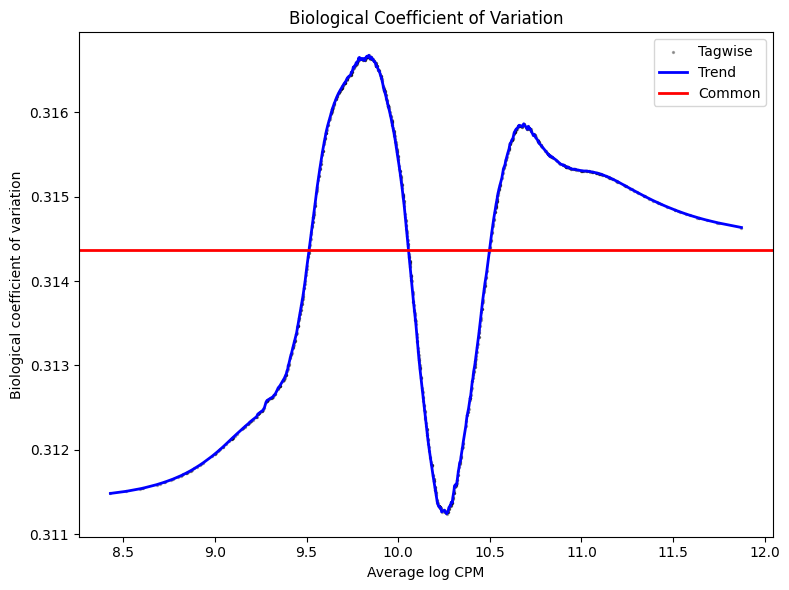

In [13]:
fig, ax = ep.plot_bcv(y)
ax.set_title('Biological Coefficient of Variation')
plt.tight_layout()
plt.show()

Fir the model

In [14]:
fit = ep.glm_ql_fit(y, design_df.values)
print(f"Prior df: {fit['df.prior']:.4f}")

Prior df: 9780.2671


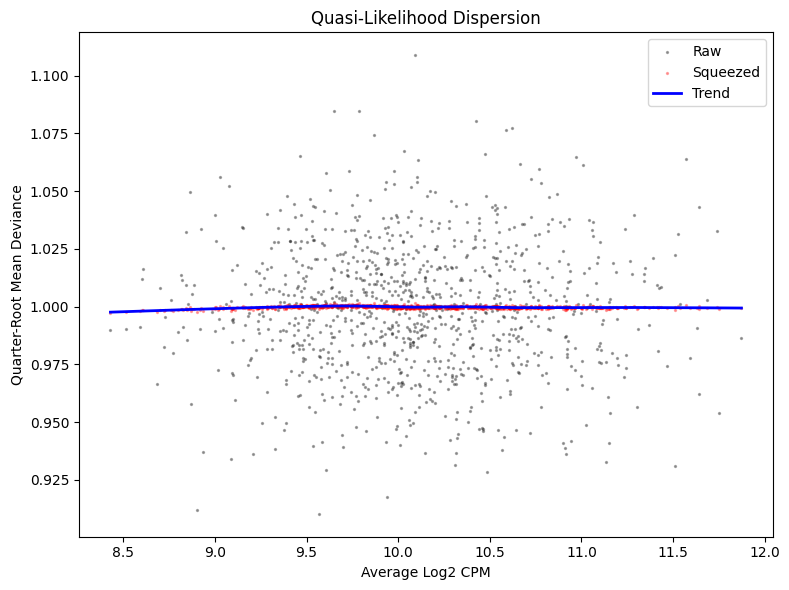

In [15]:
fig, ax = ep.plot_ql_disp(fit)
ax.set_title('Quasi-Likelihood Dispersion')
plt.tight_layout()
plt.show()

## Contrasts

In [16]:
ct = "A"
contrast = one_vs_all_contrast(design_df, ct)
test = ep.glm_ql_ftest(fit, contrast=contrast)
top = ep.top_tags(test, n=np.inf)
top

{'table':      total_counts_sum     logFC     logCPM    PValue          F       FDR
 760              1808 -0.468459  10.230701  0.000274  13.249649  0.274016
 860              1126  0.420265   9.695749  0.001854   9.693803  0.927080
 973              1787 -0.351530  10.227604  0.005653   7.661147  0.962690
 67               2848 -0.311575  10.821529  0.005705   7.644619  0.962690
 368              1353 -0.378892   9.891707  0.006128   7.515349  0.962690
 ..                ...       ...        ...       ...        ...       ...
 59               1597  0.000970  10.109991  0.993300   0.000071  0.997289
 635              3271  0.000317  11.011037  0.997357   0.000011  0.997684
 384              1700 -0.000404  10.164892  0.997425   0.000010  0.997684
 588              2454  0.000330  10.632125  0.997617   0.000009  0.997684
 27                961 -0.000388   9.530202  0.997684   0.000008  0.997684
 
 [1000 rows x 6 columns],
 'adjust.method': 'BH',
 'comparison': 'contrast',
 'test': 'gl

In [17]:
results = {}

for ct in adata.obs["celltype"].cat.categories:
    contrast = one_vs_all_contrast(design_df, ct)

    test = ep.glm_ql_ftest(fit, contrast=contrast)
    top = ep.top_tags(test, n=np.inf)

    res = top["table"].copy()
    res["celltype"] = ct
    res["peak"] = adata.var.index[top["table"].index]

    results[ct] = res.copy()

In [18]:
makerpeaks = set()
for ct, df in results.items():
    df = df[df.FDR < 0.98].sort_values("logFC", ascending=False)
    toppeaks = df.head(5)["peak"].tolist()
    makerpeaks.update(toppeaks)

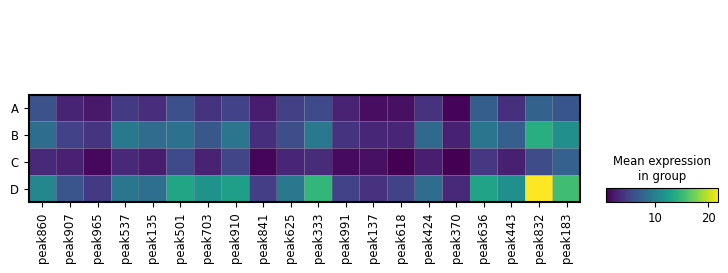

In [19]:
sc.pl.matrixplot(adata, var_names=list(makerpeaks), groupby="celltype", layer="sum")

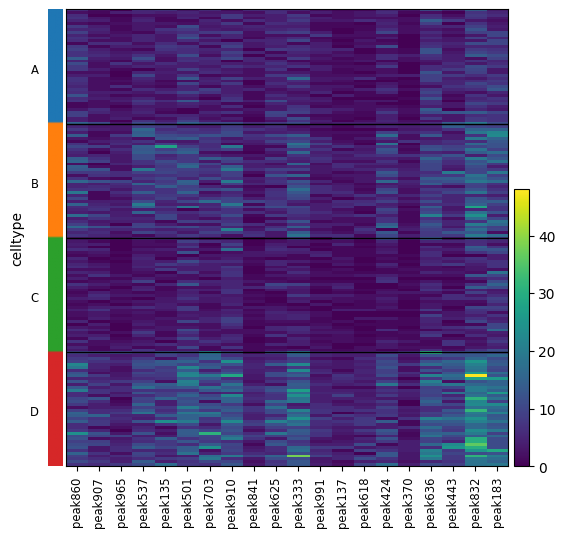

In [20]:
sc.pl.heatmap(adata, var_names=list(makerpeaks), groupby="celltype", layer="sum")